In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [3]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from src.data_utils import load_processed
from src.model import load_model

In [4]:
df = load_processed('model_ready.csv')

X = df.drop(columns='TARGET')
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [5]:
bundle = load_model('../models/bundle.pkl')

pipe_lgbm = bundle["model"]

model = pipe_lgbm.named_steps["model"]
preprocessor = pipe_lgbm.named_steps["prep"]

In [7]:
importance = model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feat_imp.head(20)

,feature,importance
160,remainder__EXT_SOURCE_3,546
158,remainder__EXT_SOURCE_1,504
159,remainder__EXT_SOURCE_2,482
137,remainder__DAYS_BIRTH,464
133,remainder__AMT_CREDIT,432
261,remainder__PREV_AVG_ANNUITY,366
134,remainder__AMT_ANNUITY,322
135,remainder__AMT_GOODS_PRICE,295
138,remainder__DAYS_EMPLOYED,287
252,remainder__BUREAU_MIN_DAYS_CREDIT,267


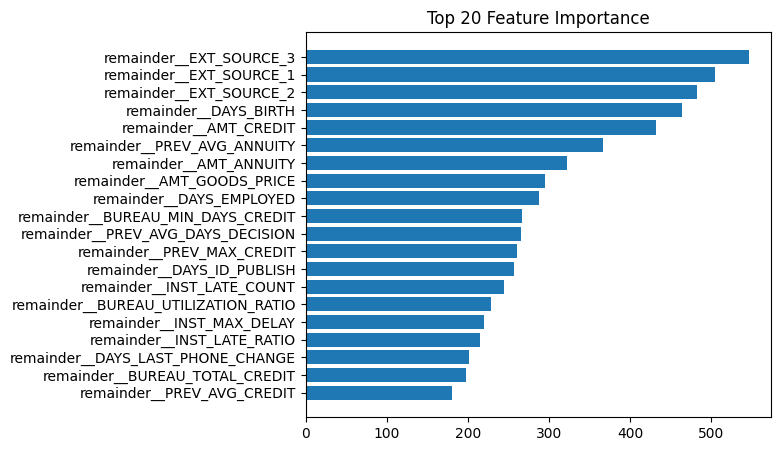

In [8]:
plt.figure(figsize=(6,5))
plt.barh(feat_imp['feature'][:20], feat_imp['importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importance')
plt.show()

In [14]:
X_train_transformed = preprocessor.transform(X_train)

In [15]:
feature_names = preprocessor.get_feature_names_out()

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

In [16]:
import shap

model = pipe_lgbm.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed_df)

# Take class 1 (positive class)
if isinstance(shap_values, list):
    shap_values = shap_values[1]   # take positive class

print(shap_values.shape)

(246008, 278)


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


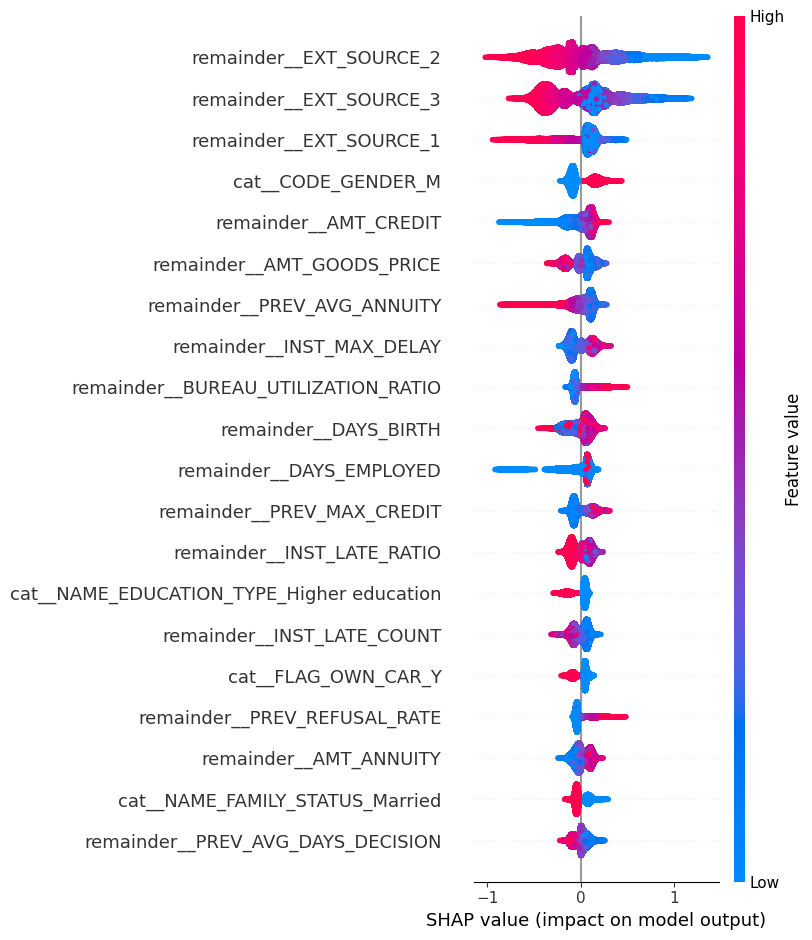

In [17]:
shap.summary_plot(
    shap_values,
    X_train_transformed_df
)

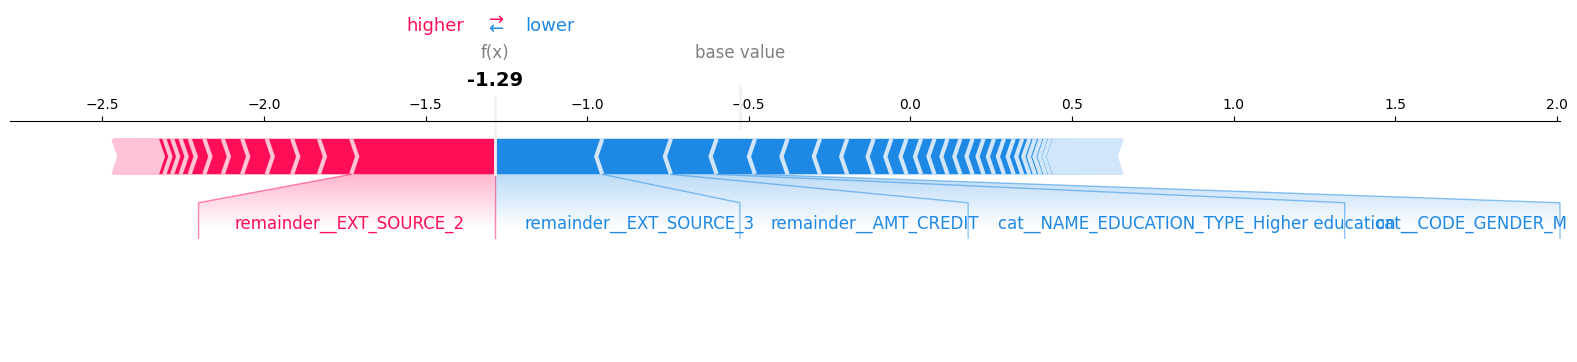

In [18]:
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    feature_names=feature_names,
    matplotlib=True
)